In [3]:
import awkward as ak
import vector
import glob
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [20]:
qq_path_t1 = glob.glob("/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/binary_classification_valid_02_epoch_5_sig_Z_test1/binary_classification/ParticleTransformer/qq_test.parquet")
z_path_t1 = glob.glob("/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/binary_classification_valid_02_epoch_5_sig_Z_test1/binary_classification/ParticleTransformer/z_test.parquet")
zh_path_t1 = glob.glob("/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/binary_classification_valid_02_epoch_5_sig_Z_test1/binary_classification/ParticleTransformer/zh_test.parquet")

qq_path_t2 = glob.glob("/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/binary_classification_valid_02_epoch_5_sig_Z_test2/binary_classification/ParticleTransformer/qq_test.parquet")
z_path_t2 = glob.glob("/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/binary_classification_valid_02_epoch_5_sig_Z_test2/binary_classification/ParticleTransformer/z_test.parquet")
zh_path_t2 = glob.glob("/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/binary_classification_valid_02_epoch_5_sig_Z_test2/binary_classification/ParticleTransformer/zh_test.parquet")

qq_path_t3 = glob.glob("/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/binary_classification_valid_02_epoch_5_sig_Z_test3/binary_classification/ParticleTransformer/qq_test.parquet")
z_path_t3 = glob.glob("/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/binary_classification_valid_02_epoch_5_sig_Z_test3/binary_classification/ParticleTransformer/z_test.parquet")
zh_path_t3 = glob.glob("/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/binary_classification_valid_02_epoch_5_sig_Z_test3/binary_classification/ParticleTransformer/zh_test.parquet")

In [21]:
qq_data1 = ak.from_parquet(qq_path_t1)
z_data1 = ak.from_parquet(z_path_t1)
zh_data1 = ak.from_parquet(zh_path_t1)

qq_data2 = ak.from_parquet(qq_path_t2)
z_data2 = ak.from_parquet(z_path_t2)
zh_data2 = ak.from_parquet(zh_path_t2)

qq_data3 = ak.from_parquet(qq_path_t3)
z_data3 = ak.from_parquet(z_path_t3)
zh_data3 = ak.from_parquet(zh_path_t3)

In [6]:
# Ver target (deben ser 0/1)
print(f"qq_data1 target: {qq_data1['binary_classification']['target'][:10]}")
print(f"z_data1 target: {z_data1['binary_classification']['target'][:10]}")
print(f"zh_data1 target: {zh_data1['binary_classification']['target'][:10]}")
print(f"\nValores únicos en qq_data1 target: {np.unique(ak.to_numpy(qq_data1['binary_classification']['target']))}")
print(f"Valores únicos en z_data1 target: {np.unique(ak.to_numpy(z_data1['binary_classification']['target']))}")
print(f"Valores únicos en zh_data1 target: {np.unique(ak.to_numpy(zh_data1['binary_classification']['target']))}")

qq_data1 target: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
z_data1 target: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
zh_data1 target: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Valores únicos en qq_data1 target: [0]
Valores únicos en z_data1 target: [1]
Valores únicos en zh_data1 target: [1]


In [7]:
# Ver los pred (0 - 1)
print(f"qq_data1 pred (primeros 10): {qq_data1['binary_classification']['pred'][:10]}")
print(f"z_data1 pred (primeros 10): {z_data1['binary_classification']['pred'][:10]}")
print(f"zh_data1 pred (primeros 10): {zh_data1['binary_classification']['pred'][:10]}")
print(f"\nRango de pred en qq_data1: min={ak.min(qq_data1['binary_classification']['pred']):.4f}, max={ak.max(qq_data1['binary_classification']['pred']):.4f}")
print(f"Rango de pred en z_data1: min={ak.min(z_data1['binary_classification']['pred']):.4f}, max={ak.max(z_data1['binary_classification']['pred']):.4f}")
print(f"Rango de pred en zh_data1: min={ak.min(zh_data1['binary_classification']['pred']):.4f}, max={ak.max(zh_data1['binary_classification']['pred']):.4f}")

qq_data1 pred (primeros 10): [0.0448, 0.00015, 0.0724, 0.00341, ..., 0.0105, 1.82e-09, 0.529, 4.28e-07]
z_data1 pred (primeros 10): [1, 1, 0.999, 1, 1, 0.997, 0.999, 0.998, 0.999, 0.994]
zh_data1 pred (primeros 10): [0.997, 1, 0.999, 0.999, 0.982, 1, 1, 1, 0.999, 0.963]

Rango de pred en qq_data1: min=0.0000, max=1.0000
Rango de pred en z_data1: min=0.0000, max=1.0000
Rango de pred en zh_data1: min=0.0000, max=1.0000


In [30]:
# Separated prediction and target data
data_pred1 = {
    'qq': qq_data1['binary_classification']['pred'],
    'z': z_data1['binary_classification']['pred'],
    'zh': zh_data1['binary_classification']['pred']
}
data_target1 = {
    'qq': qq_data1['binary_classification']['target'],
    'z': z_data1['binary_classification']['target'],
    'zh': zh_data1['binary_classification']['target']
}

data_pred2 = {
    'qq': qq_data2['binary_classification']['pred'],
    'z': z_data2['binary_classification']['pred'],
    'zh': zh_data2['binary_classification']['pred']
}
data_target2 = {
    'qq': qq_data2['binary_classification']['target'],
    'z': z_data2['binary_classification']['target'],
    'zh': zh_data2['binary_classification']['target']
}

data_pred3 = {
    'qq': qq_data3['binary_classification']['pred'],
    'z': z_data3['binary_classification']['pred'],
    'zh': zh_data3['binary_classification']['pred']
}
data_target3 = {
    'qq': qq_data3['binary_classification']['target'],
    'z': z_data3['binary_classification']['target'],
    'zh': zh_data3['binary_classification']['target']
}

In [9]:
print("Lengths of data_pred 1:")
for key, value in data_pred1.items():
    print(f"{key}: {len(value)}")

print("Lengths of data_target 1:")
for key, value in data_target1.items():
    print(f"{key}: {len(value)}")

print("Lengths of data_pred 2:")
for key, value in data_pred2.items():
    print(f"{key}: {len(value)}")

print("Lengths of data_target 2:")
for key, value in data_target2.items():
    print(f"{key}: {len(value)}")

print("Lengths of data_pred 3:")
for key, value in data_pred3.items():
    print(f"{key}: {len(value)}")

print("Lengths of data_target 3:")
for key, value in data_target3.items():
    print(f"{key}: {len(value)}")

Lengths of data_pred 1:
qq: 1425157
z: 674943
zh: 859589
Lengths of data_target 1:
qq: 1425157
z: 674943
zh: 859589
Lengths of data_pred 2:
qq: 1425157
z: 674943
zh: 859589
Lengths of data_target 2:
qq: 1425157
z: 674943
zh: 859589
Lengths of data_pred 3:
qq: 1425157
z: 674943
zh: 859589
Lengths of data_target 3:
qq: 1425157
z: 674943
zh: 859589


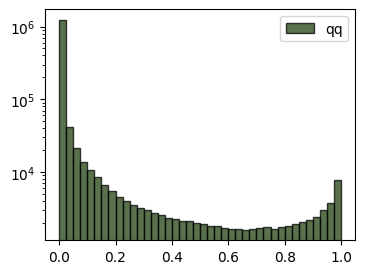

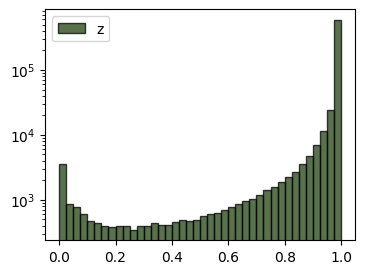

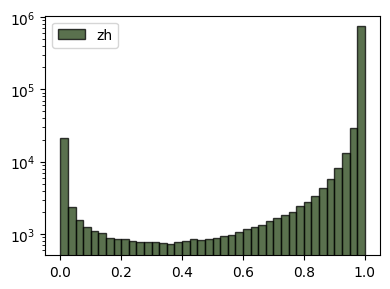

In [10]:
for i, key in enumerate(data_pred1.keys()):
    plt.figure(figsize=(4, 3))
    plt.hist(data_pred1[key], bins=40, alpha=0.75, color='#234112', edgecolor='black');
    plt.legend([key])
    plt.yscale('log')  
plt.tight_layout()
plt.show()

In [11]:
# Signal with background. But what is the signal? Z or ZH or both
signal1 = {
    'z': {
        'target': ak.concatenate([z_data1['binary_classification']['target'], qq_data1['binary_classification']['target']]),
        'pred': ak.concatenate([z_data1['binary_classification']['pred'], qq_data1['binary_classification']['pred']])
    },
    'zh': {
        'target': ak.concatenate([zh_data1['binary_classification']['target'], qq_data1['binary_classification']['target']]),
        'pred': ak.concatenate([zh_data1['binary_classification']['pred'], qq_data1['binary_classification']['pred']])
    },
    'both': {
        'target': ak.concatenate([z_data1['binary_classification']['target'], zh_data1['binary_classification']['target'], qq_data1['binary_classification']['target']]),
        'pred': ak.concatenate([z_data1['binary_classification']['pred'], zh_data1['binary_classification']['pred'], qq_data1['binary_classification']['pred']])
    }
}

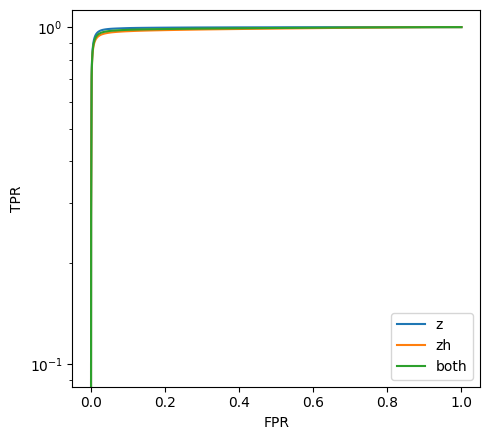

In [12]:
# ROC curve
keys =[]
plt.figure(figsize=(5,4.5))
for i, key in enumerate(signal1):
    fpr, tpr, _ = roc_curve(signal1[key]['target'], signal1[key]['pred'])
    plt.plot(fpr, tpr)  # ← CORREGIDO: FPR en X, TPR en Y
    plt.yscale('log')
    keys.append(key)
    # Uncomment to see all the plots in different figure
    #plt.show()

plt.xlabel('FPR')  # ← CORREGIDO
plt.ylabel('TPR')  # ← CORREGIDO
plt.tight_layout()

plt.legend(keys)
plt.show()

In [13]:
# Comparación de métricas entre diferentes test sets
print("=== COMPARACIÓN DE MÉTRICAS ENTRE TEST SETS ===")

from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support

# Función para calcular métricas
def calculate_metrics(target, pred, name):
    # Convertir a numpy
    y_true = ak.to_numpy(target)
    y_pred_proba = ak.to_numpy(pred)
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # AUC
    auc = roc_auc_score(y_true, y_pred_proba)
    
    # Precision, Recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    
    # Balance de clases
    signal_pct = np.mean(y_true) * 100
    
    print(f"\n{name}:")
    print(f"  • Eventos totales: {len(y_true):,}")
    print(f"  • Señal (%): {signal_pct:.1f}%")
    print(f"  • AUC: {auc:.4f}")
    print(f"  • Precision: {precision:.4f}")
    print(f"  • Recall: {recall:.4f}")
    print(f"  • F1: {f1:.4f}")
    
    return auc, precision, recall, f1, signal_pct

# Calcular para cada test set
results = {}
for i, (data_pred, data_target) in enumerate([(data_pred1, data_target1), (data_pred2, data_target2), (data_pred3, data_target3)], 1):
    print(f"\n--- TEST SET {i} ---")
    # Concatenar todos (z + zh + qq)
    all_target = ak.concatenate([data_target['z'], data_target['zh'], data_target['qq']])
    all_pred = ak.concatenate([data_pred['z'], data_pred['zh'], data_pred['qq']])
    
    results[f'test{i}'] = calculate_metrics(all_target, all_pred, f"Test Set {i}")

print("\n" + "="*50)
print("ANÁLISIS DE DIFERENCIAS:")
print("="*50)

aucs = [results[k][0] for k in results]
precisions = [results[k][1] for k in results]
recalls = [results[k][2] for k in results]
f1s = [results[k][3] for k in results]
signals = [results[k][4] for k in results]

print(f"• AUC range: {min(aucs):.4f} - {max(aucs):.4f} (diff: {max(aucs)-min(aucs):.4f})")
print(f"• Precision range: {min(precisions):.4f} - {max(precisions):.4f}")
print(f"• Recall range: {min(recalls):.4f} - {max(recalls):.4f}")
print(f"• F1 range: {min(f1s):.4f} - {max(f1s):.4f}")
print(f"• Señal % range: {min(signals):.1f}% - {max(signals):.1f}%")

print("\n📊 INTERPRETACIÓN:")
if max(aucs) - min(aucs) < 0.01:
    print("• Las métricas son MUY CONSISTENTES entre test sets")
    print("• El modelo generaliza bien a diferentes condiciones")
else:
    print("• Hay algunas diferencias entre test sets")
    print("• Posibles causas: diferentes seeds, condiciones de simulación, o variabilidad estadística")

print("\n🔬 EN FÍSICA DE PARTÍCULAS:")
print("• Diferentes test sets simulan diferentes 'experimentos' o luminosidades")
print("• Es normal tener variabilidad - lo importante es que todas sean buenas")
print("• Si diferencias >5% en AUC, investigar posibles issues de training")

=== COMPARACIÓN DE MÉTRICAS ENTRE TEST SETS ===

--- TEST SET 1 ---

Test Set 1:
  • Eventos totales: 2,959,689
  • Señal (%): 51.8%
  • AUC: 0.9898
  • Precision: 0.9702
  • Recall: 0.9660
  • F1: 0.9681

--- TEST SET 2 ---

Test Set 2:
  • Eventos totales: 2,959,689
  • Señal (%): 51.8%
  • AUC: 0.9875
  • Precision: 0.9678
  • Recall: 0.9596
  • F1: 0.9637

--- TEST SET 3 ---

Test Set 3:
  • Eventos totales: 2,959,689
  • Señal (%): 51.8%
  • AUC: 0.9881
  • Precision: 0.9792
  • Recall: 0.9492
  • F1: 0.9640

ANÁLISIS DE DIFERENCIAS:
• AUC range: 0.9875 - 0.9898 (diff: 0.0023)
• Precision range: 0.9678 - 0.9792
• Recall range: 0.9492 - 0.9660
• F1 range: 0.9637 - 0.9681
• Señal % range: 51.8% - 51.8%

📊 INTERPRETACIÓN:
• Las métricas son MUY CONSISTENTES entre test sets
• El modelo generaliza bien a diferentes condiciones

🔬 EN FÍSICA DE PARTÍCULAS:
• Diferentes test sets simulan diferentes 'experimentos' o luminosidades
• Es normal tener variabilidad - lo importante es que todas 

Confusion matrix counts for Test Set 1
[[1379584   45573]
 [  52137 1482395]]

Confusion matrix normalized by true labels (percentages)
[[96.8  3.2]
 [ 3.4 96.6]]


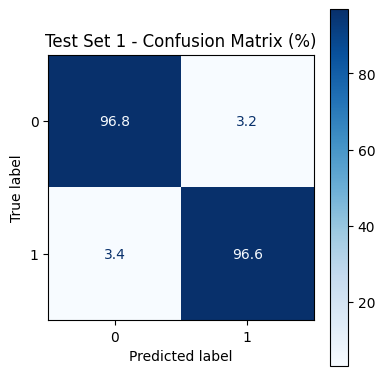

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix for Test Set 1
all_target_1 = ak.to_numpy(ak.concatenate([data_target1['z'], data_target1['zh'], data_target1['qq']]))
all_pred_proba_1 = ak.to_numpy(ak.concatenate([data_pred1['z'], data_pred1['zh'], data_pred1['qq']]))
all_pred_1 = (all_pred_proba_1 > 0.5).astype(int)

cm = confusion_matrix(all_target_1, all_pred_1)
cm_norm = confusion_matrix(all_target_1, all_pred_1, normalize='true')
print("Confusion matrix counts for Test Set 1")
print(cm)
print("\nConfusion matrix normalized by true labels (percentages)")
print(np.round(cm_norm * 100, 2))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_norm * 100, display_labels=[0, 1]).plot(ax=ax, cmap='Blues', values_format='.1f')
ax.set_title('Test Set 1 - Confusion Matrix (%)')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

Optimal threshold (max F1): 0.5756
Optimal F1 score: 0.9683

Confusion matrix with optimal threshold:
[[1385176   39981]
 [  56748 1477784]]

Normalized (%):
[[97.19  2.81]
 [ 3.7  96.3 ]]


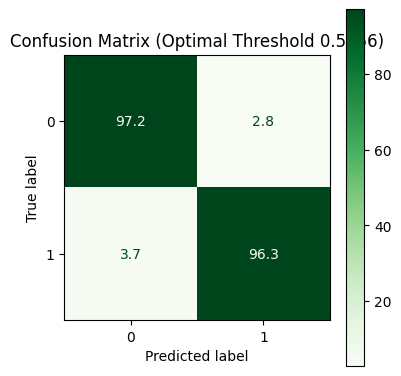

In [23]:
# Optimal Threshold Analysis
# F1 score is the harmonic mean of precision and recall: F1 = 2 * (precision * recall) / (precision + recall)
# It balances false positives and false negatives, useful for imbalanced datasets.
# Maximizing F1 gives the best trade-off between precision (correct positives / predicted positives)
# and recall (correct positives / actual positives).
# For imbalanced classes like this (background weight 10x), F1 is better than accuracy.

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(all_target_1, all_pred_proba_1)
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores = f1_scores[:-1]  # Remove last element for threshold=1
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"Optimal threshold (max F1): {optimal_threshold:.4f}")
print(f"Optimal F1 score: {optimal_f1:.4f}")

# Confusion matrix with optimal threshold
all_pred_optimal = (all_pred_proba_1 > optimal_threshold).astype(int)
cm_optimal = confusion_matrix(all_target_1, all_pred_optimal)
cm_optimal_norm = confusion_matrix(all_target_1, all_pred_optimal, normalize='true')

print("\nConfusion matrix with optimal threshold:")
print(cm_optimal)
print("\nNormalized (%):")
print(np.round(cm_optimal_norm * 100, 2))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_optimal_norm * 100, display_labels=[0, 1]).plot(ax=ax, cmap='Greens', values_format='.1f')
ax.set_title(f'Confusion Matrix (Optimal Threshold {optimal_threshold:.4f})')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

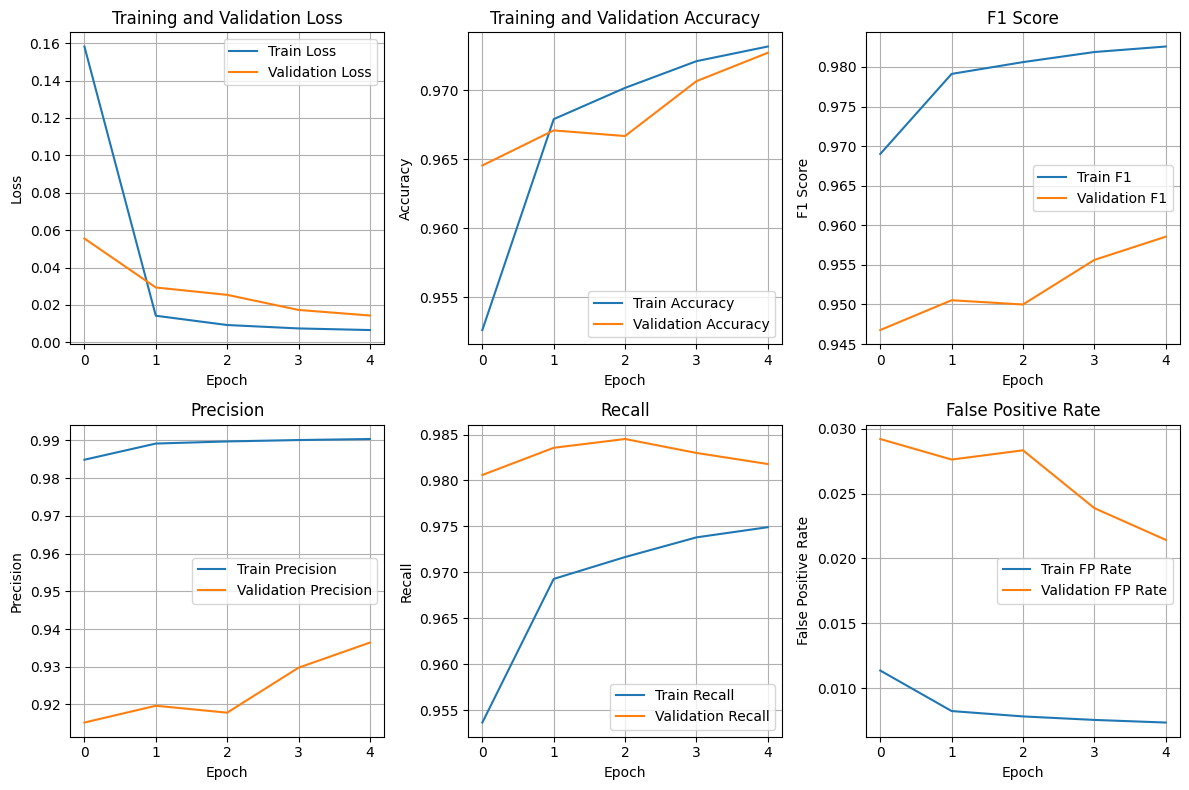

Final metrics at last epoch:
Train Loss: 0.0066
Validation Loss: 0.0144
Train Accuracy: 0.9732
Validation Accuracy: 0.9727
Train F1: 0.9826
Validation F1: 0.9586


In [25]:
# Training Metrics Analysis
# Load training history from the output directory
import json
import os

output_dir = "/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/binary_classification_valid_02_epoch_5_sig_Z_test1/binary_classification/ParticleTransformer"
history_path = os.path.join(output_dir, "history.json")

if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)

    epochs = list(range(len(history['loss_train'])))

    # Plot training and validation loss
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.plot(epochs, history['loss_train'], label='Train Loss')
    plt.plot(epochs, history['loss_validation'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    # Plot accuracy
    plt.subplot(2, 3, 2)
    plt.plot(epochs, history['accuracy_train'], label='Train Accuracy')
    plt.plot(epochs, history['accuracy_validation'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot F1 score
    plt.subplot(2, 3, 3)
    plt.plot(epochs, history['F1_train'], label='Train F1')
    plt.plot(epochs, history['F1_validation'], label='Validation F1')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.title('F1 Score')
    plt.legend()
    plt.grid(True)

    # Plot Precision
    plt.subplot(2, 3, 4)
    plt.plot(epochs, history['precision_train'], label='Train Precision')
    plt.plot(epochs, history['precision_validation'], label='Validation Precision')
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.title('Precision')
    plt.legend()
    plt.grid(True)

    # Plot Recall
    plt.subplot(2, 3, 5)
    plt.plot(epochs, history['recall_train'], label='Train Recall')
    plt.plot(epochs, history['recall_validation'], label='Validation Recall')
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.title('Recall')
    plt.legend()
    plt.grid(True)

    # Plot False Positive Rate
    plt.subplot(2, 3, 6)
    plt.plot(epochs, history['false_positives_train'], label='Train FP Rate')
    plt.plot(epochs, history['false_positives_validation'], label='Validation FP Rate')
    plt.xlabel('Epoch')
    plt.ylabel('False Positive Rate')
    plt.title('False Positive Rate')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print("Final metrics at last epoch:")
    print(f"Train Loss: {history['loss_train'][-1]:.4f}")
    print(f"Validation Loss: {history['loss_validation'][-1]:.4f}")
    print(f"Train Accuracy: {history['accuracy_train'][-1]:.4f}")
    print(f"Validation Accuracy: {history['accuracy_validation'][-1]:.4f}")
    print(f"Train F1: {history['F1_train'][-1]:.4f}")
    print(f"Validation F1: {history['F1_validation'][-1]:.4f}")

else:
    print("History file not found. Make sure the training completed and saved history.json")

AUC for Test Set 1: 0.9898
AUC for Test Set 2: 0.9875
AUC for Test Set 3: 0.9881


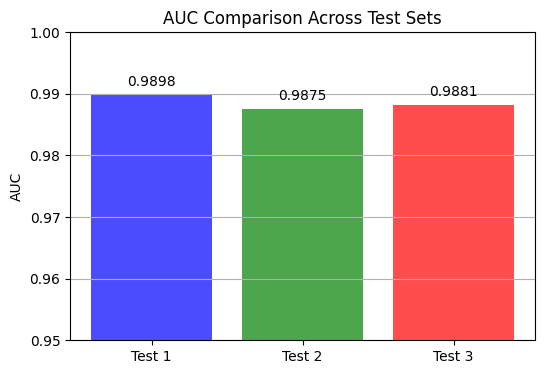

In [26]:
# AUC Analysis
# Note: AUC is not logged in history.json during training.
# The training script logs ROC curves to TensorBoard but not AUC scalars.
# Here we compute AUC for the test sets as evaluation metrics.

from sklearn.metrics import roc_auc_score

# Compute AUC for each test set
auc_test1 = roc_auc_score(all_target_1, all_pred_proba_1)
print(f"AUC for Test Set 1: {auc_test1:.4f}")

# For other test sets
all_target_2 = ak.to_numpy(ak.concatenate([data_target2['z'], data_target2['zh'], data_target2['qq']]))
all_pred_proba_2 = ak.to_numpy(ak.concatenate([data_pred2['z'], data_pred2['zh'], data_pred2['qq']]))
auc_test2 = roc_auc_score(all_target_2, all_pred_proba_2)
print(f"AUC for Test Set 2: {auc_test2:.4f}")

all_target_3 = ak.to_numpy(ak.concatenate([data_target3['z'], data_target3['zh'], data_target3['qq']]))
all_pred_proba_3 = ak.to_numpy(ak.concatenate([data_pred3['z'], data_pred3['zh'], data_pred3['qq']]))
auc_test3 = roc_auc_score(all_target_3, all_pred_proba_3)
print(f"AUC for Test Set 3: {auc_test3:.4f}")

# Plot AUC comparison
test_sets = ['Test 1', 'Test 2', 'Test 3']
auc_values = [auc_test1, auc_test2, auc_test3]

plt.figure(figsize=(6, 4))
plt.bar(test_sets, auc_values, color=['blue', 'green', 'red'], alpha=0.7)
plt.ylabel('AUC')
plt.title('AUC Comparison Across Test Sets')
plt.ylim(0.95, 1.0)  # Adjust based on your values
plt.grid(True, axis='y')
for i, v in enumerate(auc_values):
    plt.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')
plt.show()

# If you want AUC vs epoch, you would need to modify the training script to log it.
# For now, the ROC curves are available in TensorBoard logs.

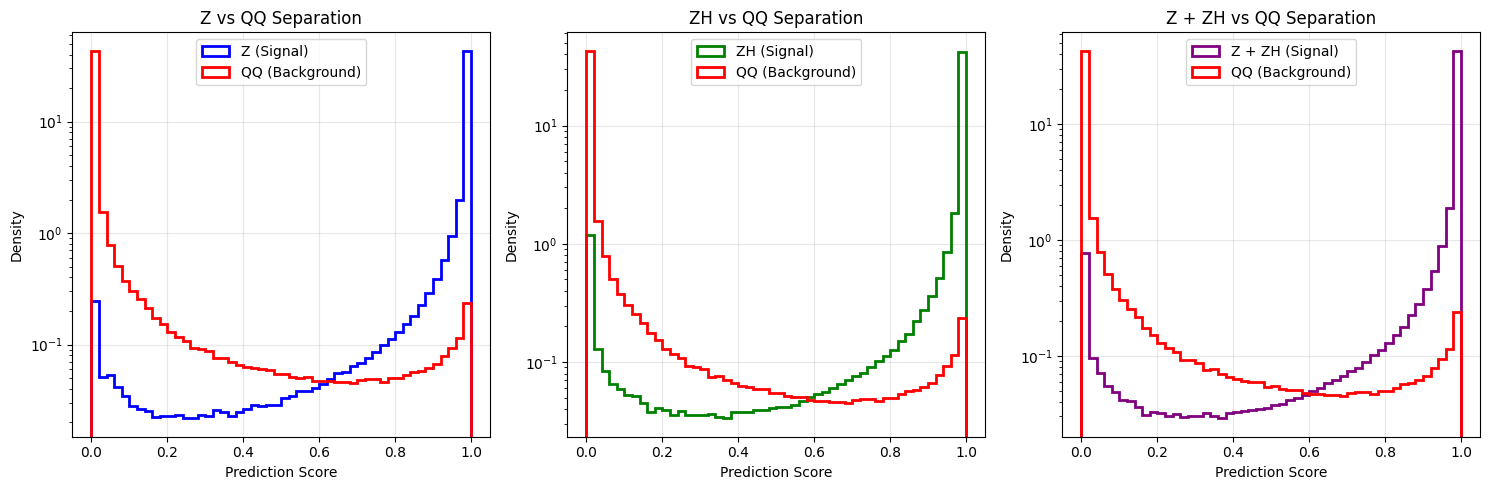

Separation Statistics (Test Set 1):
Z mean score: 0.9711, QQ mean score: 0.0409
ZH mean score: 0.9450, QQ mean score: 0.0409
Z+ZH mean score: 0.9565, QQ mean score: 0.0409

Separation (mean difference):
Z - QQ: 0.9302
ZH - QQ: 0.9041
Z+ZH - QQ: 0.9156


In [29]:
# Score Distribution Analysis: Signal vs Background Separation
# Plot prediction score distributions to visualize separation power
# Using line histograms to see crossing points clearly

plt.figure(figsize=(15, 5))

# Plot 1: Z (signal) vs QQ (background)
plt.subplot(1, 3, 1)
plt.hist(ak.to_numpy(data_pred1['z']), bins=50, histtype='step', linewidth=2, color='blue', label='Z (Signal)', density=True)
plt.hist(ak.to_numpy(data_pred1['qq']), bins=50, histtype='step', linewidth=2, color='red', label='QQ (Background)', density=True)
plt.xlabel('Prediction Score')
plt.ylabel('Density')
plt.title('Z vs QQ Separation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot 2: ZH (signal) vs QQ (background)
plt.subplot(1, 3, 2)
plt.hist(ak.to_numpy(data_pred1['zh']), bins=50, histtype='step', linewidth=2, color='green', label='ZH (Signal)', density=True)
plt.hist(ak.to_numpy(data_pred1['qq']), bins=50, histtype='step', linewidth=2, color='red', label='QQ (Background)', density=True)
plt.xlabel('Prediction Score')
plt.ylabel('Density')
plt.title('ZH vs QQ Separation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot 3: Z + ZH (signal) vs QQ (background)
plt.subplot(1, 3, 3)
combined_signal = ak.concatenate([data_pred1['z'], data_pred1['zh']])
plt.hist(ak.to_numpy(combined_signal), bins=50, histtype='step', linewidth=2, color='purple', label='Z + ZH (Signal)', density=True)
plt.hist(ak.to_numpy(data_pred1['qq']), bins=50, histtype='step', linewidth=2, color='red', label='QQ (Background)', density=True)
plt.xlabel('Prediction Score')
plt.ylabel('Density')
plt.title('Z + ZH vs QQ Separation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

# Print some statistics
print("Separation Statistics (Test Set 1):")
print(f"Z mean score: {ak.mean(data_pred1['z']):.4f}, QQ mean score: {ak.mean(data_pred1['qq']):.4f}")
print(f"ZH mean score: {ak.mean(data_pred1['zh']):.4f}, QQ mean score: {ak.mean(data_pred1['qq']):.4f}")
combined_mean = ak.mean(combined_signal)
print(f"Z+ZH mean score: {combined_mean:.4f}, QQ mean score: {ak.mean(data_pred1['qq']):.4f}")

# Separation power (difference in means)
sep_z = ak.mean(data_pred1['z']) - ak.mean(data_pred1['qq'])
sep_zh = ak.mean(data_pred1['zh']) - ak.mean(data_pred1['qq'])
sep_combined = combined_mean - ak.mean(data_pred1['qq'])
print(f"\nSeparation (mean difference):")
print(f"Z - QQ: {sep_z:.4f}")
print(f"ZH - QQ: {sep_zh:.4f}")
print(f"Z+ZH - QQ: {sep_combined:.4f}")

In [33]:
# Bimodal Distribution Analysis
# Let's investigate what's causing the secondary peaks in the score distributions

import numpy as np
from scipy import stats

print("=== BIMODAL DISTRIBUTION ANALYSIS ===")

# Function to analyze distribution characteristics
def analyze_distribution(scores, label):
    scores_np = ak.to_numpy(scores)

    # Basic statistics
    mean = np.mean(scores_np)
    std = np.std(scores_np)
    median = np.median(scores_np)
    skewness = stats.skew(scores_np)
    kurtosis = stats.kurtosis(scores_np)

    # Find peaks using kernel density estimation
    from scipy.signal import find_peaks
    kde = stats.gaussian_kde(scores_np)
    x_range = np.linspace(0, 1, 1000)
    density = kde(x_range)
    peaks, properties = find_peaks(density, height=0.05, distance=100)

    print(f"\n{label}:")
    print(f"  • Mean: {mean:.4f}, Std: {std:.4f}, Median: {median:.4f}")
    print(f"  • Skewness: {skewness:.4f}, Kurtosis: {kurtosis:.4f}")
    print(f"  • Number of peaks detected: {len(peaks)}")
    if len(peaks) > 0:
        peak_positions = x_range[peaks]
        peak_heights = properties['peak_heights']
        print(f"  • Peak positions: {peak_positions}")
        print(f"  • Peak heights: {peak_heights}")

    return len(peaks), skewness, kurtosis

# Analyze each distribution
qq_peaks, qq_skew, qq_kurt = analyze_distribution(data_pred1['qq'], "QQ (Background)")
z_peaks, z_skew, z_kurt = analyze_distribution(data_pred1['z'], "Z (Signal)")
zh_peaks, zh_skew, zh_kurt = analyze_distribution(data_pred1['zh'], "ZH (Signal)")

print("\n📊 INTERPRETATION:")
print("• Multiple peaks suggest bimodality (multimodal distribution)")
print("• High kurtosis (> 3) indicates heavy tails, potential subgroups")
print("• High absolute skewness indicates asymmetry in the distribution")

if qq_peaks > 1 or z_peaks > 1 or zh_peaks > 1:
    print("\n🔍 POSSIBLE CAUSES OF BIMODALITY:")
    print("1. Subgroups in data: Different types of jets/events with different characteristics")
    print("2. Model learning different decision boundaries for different kinematic regions")
    print("3. Class imbalance effects: Model pushes some background events to higher scores")
    print("4. Feature correlations: Certain jet features correlate with classification difficulty")

    print("\n🛠️ INVESTIGATION STEPS:")
    print("• Check correlations with jet pT, eta, phi, mass, etc.")
    print("• Look at distributions in different kinematic bins")
    print("• Examine training data for inherent subgroups")
    print("• Consider model calibration techniques")

print("\n" + "="*60)

=== BIMODAL DISTRIBUTION ANALYSIS ===

QQ (Background):
  • Mean: 0.0409, Std: 0.1518, Median: 0.0002
  • Skewness: 4.7169, Kurtosis: 22.5749
  • Number of peaks detected: 6
  • Peak positions: [0.001001   0.34034034 0.45345345 0.56856857 0.8018018  0.99199199]
  • Peak heights: [36.65086644  0.07713303  0.06015507  0.05069996  0.05034048  0.18115064]

Z (Signal):
  • Mean: 0.9711, Std: 0.1215, Median: 0.9995
  • Skewness: -6.1301, Kurtosis: 39.9653
  • Number of peaks detected: 2
  • Peak positions: [0.003003 0.998999]
  • Peak heights: [ 0.20097762 38.99547063]

ZH (Signal):
  • Mean: 0.9450, Std: 0.1935, Median: 0.9994
  • Skewness: -4.1102, Kurtosis: 15.9297
  • Number of peaks detected: 2
  • Peak positions: [0.003003 0.997998]
  • Peak heights: [ 0.72061502 26.01460973]

📊 INTERPRETATION:
• Multiple peaks suggest bimodality (multimodal distribution)
• High kurtosis (> 3) indicates heavy tails, potential subgroups
• High absolute skewness indicates asymmetry in the distribution

🔍